# Part 4: 실험 결과 비교 및 시각화

## 이 노트북에서 다루는 내용
1. 모든 방법 통합 실험
2. 하이퍼파라미터 튜닝 (Temperature, Loss weights)
3. 학습 곡선 시각화
4. 최종 성능 비교 테이블
5. 결론 및 인사이트

---

## 실험 구성
1. **Baseline**: Student만 CE loss로 학습
2. **Soft Target KD**: Teacher의 soft targets 사용
3. **Cosine Loss**: Hidden representation 유사도 최대화
4. **MSE Regressor**: Feature map 모방 (FitNets)

## 1. 환경 설정 및 라이브러리 Import

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from module.models import (
    DeepNN, LightNN,
    ModifiedDeepNNCosine, ModifiedLightNNCosine,
    ModifiedDeepNNRegressor, ModifiedLightNNRegressor
)

In [3]:
def get_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


DEVICE = get_device()
print(f"Using device: {DEVICE}")

# 하이퍼파라미터
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.001
NUM_CLASSES = 10
SEED = 42

# 결과 저장 디렉토리
os.makedirs('results', exist_ok=True)

Using device: cuda


## 2. 데이터 로드

In [4]:
def get_data_loaders(batch_size: int = 128):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    train_dataset = datasets.CIFAR10(root='./data/datasets', train=True, download=True, transform=transform)
    test_dataset = datasets.CIFAR10(root='./data/datasets', train=False, download=True, transform=transform)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                              num_workers=0, pin_memory=True if DEVICE == "cuda" else False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, 
                             num_workers=0, pin_memory=True if DEVICE == "cuda" else False)
    
    return train_loader, test_loader

In [5]:
print("[1] 데이터 로드...")
train_loader, test_loader = get_data_loaders(BATCH_SIZE)
print(f"    학습: {len(train_loader.dataset):,}장, 테스트: {len(test_loader.dataset):,}장")

[1] 데이터 로드...
    학습: 50,000장, 테스트: 10,000장


## 3. 학습 함수들 정의

In [6]:
def train_baseline(model, train_loader, epochs, lr, device):
    """일반 CE 학습"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.to(device)
    model.train()
    
    losses = []
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"  Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")
    return losses

In [7]:
def train_soft_target_kd(teacher, student, train_loader, epochs, lr, T, alpha, device):
    """Soft Target KD"""
    ce_loss = nn.CrossEntropyLoss()
    optimizer = optim.Adam(student.parameters(), lr=lr)
    
    teacher.to(device)
    student.to(device)
    teacher.eval()
    student.train()
    
    losses = []
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            with torch.no_grad():
                teacher_logits = teacher(inputs)
            
            student_logits = student(inputs)
            
            soft_targets = nn.functional.softmax(teacher_logits / T, dim=-1)
            soft_prob = nn.functional.log_softmax(student_logits / T, dim=-1)
            kd_loss = torch.sum(soft_targets * (soft_targets.log() - soft_prob)) / soft_prob.size(0) * (T ** 2)
            
            label_loss = ce_loss(student_logits, labels)
            loss = alpha * kd_loss + (1 - alpha) * label_loss
            
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        avg_loss = running_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"  Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")
    return losses

In [8]:
def train_cosine(teacher, student, train_loader, epochs, lr, alpha, device):
    """Cosine Similarity Loss"""
    ce_loss = nn.CrossEntropyLoss()
    cosine_loss = nn.CosineEmbeddingLoss()
    optimizer = optim.Adam(student.parameters(), lr=lr)
    
    teacher.to(device)
    student.to(device)
    teacher.eval()
    student.train()
    
    losses = []
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            with torch.no_grad():
                _, teacher_hidden = teacher(inputs)
            
            student_logits, student_hidden = student(inputs)
            
            target = torch.ones(inputs.size(0)).to(device)
            hidden_loss = cosine_loss(student_hidden, teacher_hidden, target)
            label_loss = ce_loss(student_logits, labels)
            loss = alpha * hidden_loss + (1 - alpha) * label_loss
            
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        avg_loss = running_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"  Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")
    return losses

In [9]:
def train_mse_regressor(teacher, student, train_loader, epochs, lr, alpha, device):
    """MSE Feature Map Loss (FitNets)"""
    ce_loss = nn.CrossEntropyLoss()
    mse_loss = nn.MSELoss()
    optimizer = optim.Adam(student.parameters(), lr=lr)
    
    teacher.to(device)
    student.to(device)
    teacher.eval()
    student.train()
    
    losses = []
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            with torch.no_grad():
                _, teacher_fm = teacher(inputs)
            
            student_logits, student_fm = student(inputs)
            
            feature_loss = mse_loss(student_fm, teacher_fm)
            label_loss = ce_loss(student_logits, labels)
            loss = alpha * feature_loss + (1 - alpha) * label_loss
            
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        avg_loss = running_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"  Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")
    return losses

## 4. 평가 함수

In [10]:
def test(model, test_loader, device, multiple_outputs=False):
    model.to(device)
    model.eval()
    
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            if multiple_outputs:
                outputs, _ = model(inputs)
            else:
                outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return 100 * correct / total

## 5. 시각화 함수들

In [11]:
def plot_training_curves(all_losses: dict, save_path: str = 'results/training_curves.png'):
    """학습 곡선 시각화"""
    plt.figure(figsize=(12, 6))
    
    for name, losses in all_losses.items():
        plt.plot(range(1, len(losses) + 1), losses, label=name, linewidth=2)
    
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Training Loss Curves - Knowledge Distillation Methods', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"학습 곡선 저장: {save_path}")

In [12]:
def plot_accuracy_comparison(results: dict, save_path: str = 'results/accuracy_comparison.png'):
    """정확도 비교 바 차트"""
    methods = list(results.keys())
    accuracies = list(results.values())
    
    # 색상 설정 (Baseline보다 높으면 녹색, 낮으면 빨강)
    baseline_acc = results.get('Baseline', 0)
    colors = ['#2196F3' if 'Teacher' in m else 
              ('#4CAF50' if acc > baseline_acc else '#F44336' if acc < baseline_acc else '#9E9E9E')
              for m, acc in zip(methods, accuracies)]
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(methods, accuracies, color=colors, edgecolor='black', linewidth=1.2)
    
    # 값 표시
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, 
                 f'{acc:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.xlabel('Method', fontsize=12)
    plt.ylabel('Test Accuracy (%)', fontsize=12)
    plt.title('Knowledge Distillation - Test Accuracy Comparison', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(min(accuracies) - 3, max(accuracies) + 3)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"정확도 비교 차트 저장: {save_path}")

In [13]:
def plot_temperature_experiment(temp_results: dict, save_path: str = 'results/temperature_experiment.png'):
    """Temperature 실험 결과 시각화"""
    temps = list(temp_results.keys())
    accs = list(temp_results.values())
    
    plt.figure(figsize=(10, 6))
    plt.plot(temps, accs, 'bo-', linewidth=2, markersize=10)
    
    # 최적 Temperature 표시
    best_temp = temps[np.argmax(accs)]
    best_acc = max(accs)
    plt.axvline(x=best_temp, color='r', linestyle='--', alpha=0.7, label=f'Best T={best_temp}')
    plt.scatter([best_temp], [best_acc], color='red', s=200, zorder=5, marker='*')
    
    plt.xlabel('Temperature (T)', fontsize=12)
    plt.ylabel('Test Accuracy (%)', fontsize=12)
    plt.title('Effect of Temperature on Soft Target KD', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Temperature 실험 결과 저장: {save_path}")

In [14]:
def create_summary_table(results: dict, save_path: str = 'results/summary.txt'):
    """결과 요약 테이블 생성"""
    baseline_acc = results.get('Baseline', 0)
    
    lines = [
        "=" * 70,
        "Knowledge Distillation 실험 결과 요약",
        "=" * 70,
        "",
        f"{'Method':<35} {'Accuracy':<12} {'vs Baseline':<12}",
        "-" * 70,
    ]
    
    for method, acc in results.items():
        diff = acc - baseline_acc if method != 'Baseline' and method != 'Teacher' else 0
        diff_str = f"{diff:+.2f}%" if diff != 0 else "-"
        lines.append(f"{method:<35} {acc:>10.2f}% {diff_str:>12}")
    
    lines.extend([
        "-" * 70,
        "",
        "분석:",
    ])
    
    # 최고 성능 방법 찾기 (Teacher 제외)
    student_results = {k: v for k, v in results.items() if k != 'Teacher'}
    best_method = max(student_results, key=student_results.get)
    best_acc = student_results[best_method]
    
    lines.extend([
        f"- 최고 Student 성능: {best_method} ({best_acc:.2f}%)",
        f"- Baseline 대비 개선: {best_acc - baseline_acc:+.2f}%",
        f"- Teacher와의 격차: {results.get('Teacher', 0) - best_acc:.2f}%",
    ])
    
    content = "\n".join(lines)
    print(content)
    
    with open(save_path, 'w', encoding='utf-8') as f:
        f.write(content)
    print(f"\n결과 요약 저장: {save_path}")

## 6. 종합 실험 실행

모든 Knowledge Distillation 방법을 실행하고 결과를 비교합니다.

In [15]:
# 결과 저장용 딕셔너리
all_losses = {}
all_accuracies = {}

### 6.1 Teacher 모델 준비

In [16]:
print("\n[2] Teacher 모델 준비...")
teacher = DeepNN(num_classes=NUM_CLASSES).to(DEVICE)

try:
    teacher.load_state_dict(torch.load('./data/trained_models/teacher_model.pth', map_location=DEVICE, weights_only=True))
    print("    저장된 Teacher 로드 완료")
except FileNotFoundError:
    print("    Teacher 학습 중...")
    torch.manual_seed(SEED)
    train_baseline(teacher, train_loader, EPOCHS, LEARNING_RATE, DEVICE)
    torch.save(teacher.state_dict(), './data/trained_models/teacher_model.pth')

teacher_acc = test(teacher, test_loader, DEVICE)
all_accuracies['Teacher'] = teacher_acc
print(f"    Teacher Accuracy: {teacher_acc:.2f}%")


[2] Teacher 모델 준비...
    저장된 Teacher 로드 완료
    Teacher Accuracy: 75.01%


### 6.2 Baseline (CE only)

In [17]:
print("\n[3] Baseline (CE only)...")
torch.manual_seed(SEED)
student_baseline = LightNN(num_classes=NUM_CLASSES).to(DEVICE)
baseline_losses = train_baseline(student_baseline, train_loader, EPOCHS, LEARNING_RATE, DEVICE)
baseline_acc = test(student_baseline, test_loader, DEVICE)

all_losses['Baseline'] = baseline_losses
all_accuracies['Baseline'] = baseline_acc
print(f"    Baseline Accuracy: {baseline_acc:.2f}%")


[3] Baseline (CE only)...
  Epoch 1/10, Loss: 1.4696
  Epoch 2/10, Loss: 1.1577
  Epoch 3/10, Loss: 1.0257
  Epoch 4/10, Loss: 0.9229
  Epoch 5/10, Loss: 0.8472
  Epoch 6/10, Loss: 0.7802
  Epoch 7/10, Loss: 0.7143
  Epoch 8/10, Loss: 0.6583
  Epoch 9/10, Loss: 0.6051
  Epoch 10/10, Loss: 0.5556
    Baseline Accuracy: 70.53%


### 6.3 Soft Target KD

In [18]:
print("\n[4] Soft Target KD (T=2, α=0.25)...")
torch.manual_seed(SEED)
student_soft_kd = LightNN(num_classes=NUM_CLASSES).to(DEVICE)
soft_kd_losses = train_soft_target_kd(
    teacher, student_soft_kd, train_loader, 
    EPOCHS, LEARNING_RATE, T=2.0, alpha=0.25, device=DEVICE
)
soft_kd_acc = test(student_soft_kd, test_loader, DEVICE)

all_losses['Soft Target KD'] = soft_kd_losses
all_accuracies['Soft Target KD'] = soft_kd_acc
print(f"    Soft Target KD Accuracy: {soft_kd_acc:.2f}%")


[4] Soft Target KD (T=2, α=0.25)...
  Epoch 1/10, Loss: 2.3356
  Epoch 2/10, Loss: 1.8275
  Epoch 3/10, Loss: 1.6105
  Epoch 4/10, Loss: 1.4434
  Epoch 5/10, Loss: 1.3230
  Epoch 6/10, Loss: 1.2168
  Epoch 7/10, Loss: 1.1208
  Epoch 8/10, Loss: 1.0264
  Epoch 9/10, Loss: 0.9502
  Epoch 10/10, Loss: 0.8809
    Soft Target KD Accuracy: 71.14%


### 6.4 Cosine Similarity Loss

In [19]:
print("\n[5] Cosine Similarity Loss...")
teacher_cosine = ModifiedDeepNNCosine(num_classes=NUM_CLASSES).to(DEVICE)
teacher_cosine.load_state_dict(teacher.state_dict())

torch.manual_seed(SEED)
student_cosine = ModifiedLightNNCosine(num_classes=NUM_CLASSES).to(DEVICE)
cosine_losses = train_cosine(
    teacher_cosine, student_cosine, train_loader,
    EPOCHS, LEARNING_RATE, alpha=0.25, device=DEVICE
)
cosine_acc = test(student_cosine, test_loader, DEVICE, multiple_outputs=True)

all_losses['Cosine Loss'] = cosine_losses
all_accuracies['Cosine Loss'] = cosine_acc
print(f"    Cosine Loss Accuracy: {cosine_acc:.2f}%")


[5] Cosine Similarity Loss...
  Epoch 1/10, Loss: 1.2915
  Epoch 2/10, Loss: 1.0642
  Epoch 3/10, Loss: 0.9720
  Epoch 4/10, Loss: 0.9022
  Epoch 5/10, Loss: 0.8498
  Epoch 6/10, Loss: 0.8045
  Epoch 7/10, Loss: 0.7607
  Epoch 8/10, Loss: 0.7231
  Epoch 9/10, Loss: 0.6894
  Epoch 10/10, Loss: 0.6593
    Cosine Loss Accuracy: 70.37%


### 6.5 MSE Regressor (FitNets)

In [20]:
print("\n[6] MSE Regressor (FitNets)...")
teacher_reg = ModifiedDeepNNRegressor(num_classes=NUM_CLASSES).to(DEVICE)
teacher_reg.load_state_dict(teacher.state_dict())

torch.manual_seed(SEED)
student_reg = ModifiedLightNNRegressor(num_classes=NUM_CLASSES).to(DEVICE)
mse_losses = train_mse_regressor(
    teacher_reg, student_reg, train_loader,
    EPOCHS, LEARNING_RATE, alpha=0.25, device=DEVICE
)
mse_acc = test(student_reg, test_loader, DEVICE, multiple_outputs=True)

all_losses['MSE Regressor'] = mse_losses
all_accuracies['MSE Regressor'] = mse_acc
print(f"    MSE Regressor Accuracy: {mse_acc:.2f}%")


[6] MSE Regressor (FitNets)...
  Epoch 1/10, Loss: 1.6801
  Epoch 2/10, Loss: 1.3152
  Epoch 3/10, Loss: 1.1667
  Epoch 4/10, Loss: 1.0737
  Epoch 5/10, Loss: 1.0026
  Epoch 6/10, Loss: 0.9380
  Epoch 7/10, Loss: 0.8899
  Epoch 8/10, Loss: 0.8427
  Epoch 9/10, Loss: 0.8038
  Epoch 10/10, Loss: 0.7681
    MSE Regressor Accuracy: 69.98%


## 7. Temperature 실험

Temperature 값에 따른 Soft Target KD 성능 변화를 확인합니다.

In [21]:
print("\n[7] Temperature 실험 (T = 1, 2, 4, 8, 16)...")
temp_results = {}

for T in [1, 2, 4, 8, 16]:
    print(f"\n    T={T}:")
    torch.manual_seed(SEED)
    student_temp = LightNN(num_classes=NUM_CLASSES).to(DEVICE)
    train_soft_target_kd(teacher, student_temp, train_loader, EPOCHS, LEARNING_RATE, T=T, alpha=0.25, device=DEVICE)
    acc = test(student_temp, test_loader, DEVICE)
    temp_results[T] = acc
    print(f"    T={T}: {acc:.2f}%")


[7] Temperature 실험 (T = 1, 2, 4, 8, 16)...

    T=1:
  Epoch 1/10, Loss: nan
  Epoch 2/10, Loss: nan
  Epoch 3/10, Loss: nan
  Epoch 4/10, Loss: nan
  Epoch 5/10, Loss: nan
  Epoch 6/10, Loss: nan
  Epoch 7/10, Loss: nan
  Epoch 8/10, Loss: nan
  Epoch 9/10, Loss: nan
  Epoch 10/10, Loss: nan
    T=1: 70.37%

    T=2:
  Epoch 1/10, Loss: 2.3356
  Epoch 2/10, Loss: 1.8275
  Epoch 3/10, Loss: 1.6105
  Epoch 4/10, Loss: 1.4434
  Epoch 5/10, Loss: 1.3230
  Epoch 6/10, Loss: 1.2168
  Epoch 7/10, Loss: 1.1208
  Epoch 8/10, Loss: 1.0264
  Epoch 9/10, Loss: 0.9502
  Epoch 10/10, Loss: 0.8809
    T=2: 71.14%

    T=4:
  Epoch 1/10, Loss: 4.5869
  Epoch 2/10, Loss: 3.4999
  Epoch 3/10, Loss: 3.0325
  Epoch 4/10, Loss: 2.6948
  Epoch 5/10, Loss: 2.4379
  Epoch 6/10, Loss: 2.2186
  Epoch 7/10, Loss: 2.0313
  Epoch 8/10, Loss: 1.8684
  Epoch 9/10, Loss: 1.7388
  Epoch 10/10, Loss: 1.6294
    T=4: 70.47%

    T=8:
  Epoch 1/10, Loss: 7.5746
  Epoch 2/10, Loss: 5.4616
  Epoch 3/10, Loss: 4.6225
  Ep

## 8. 결과 시각화

In [22]:
print("\n[8] 결과 시각화...")


[8] 결과 시각화...


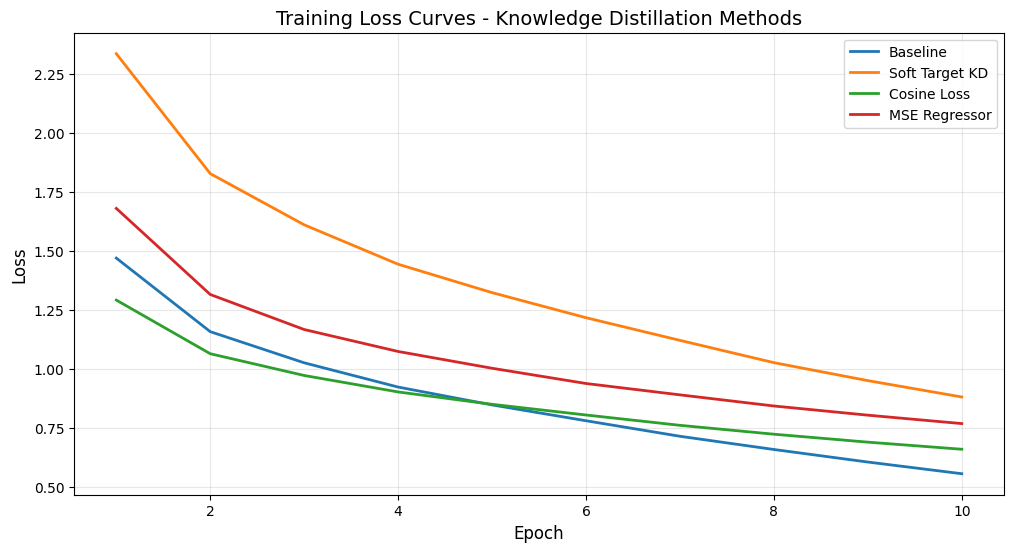

학습 곡선 저장: results/training_curves.png


In [23]:
# 학습 곡선
plot_training_curves(all_losses)

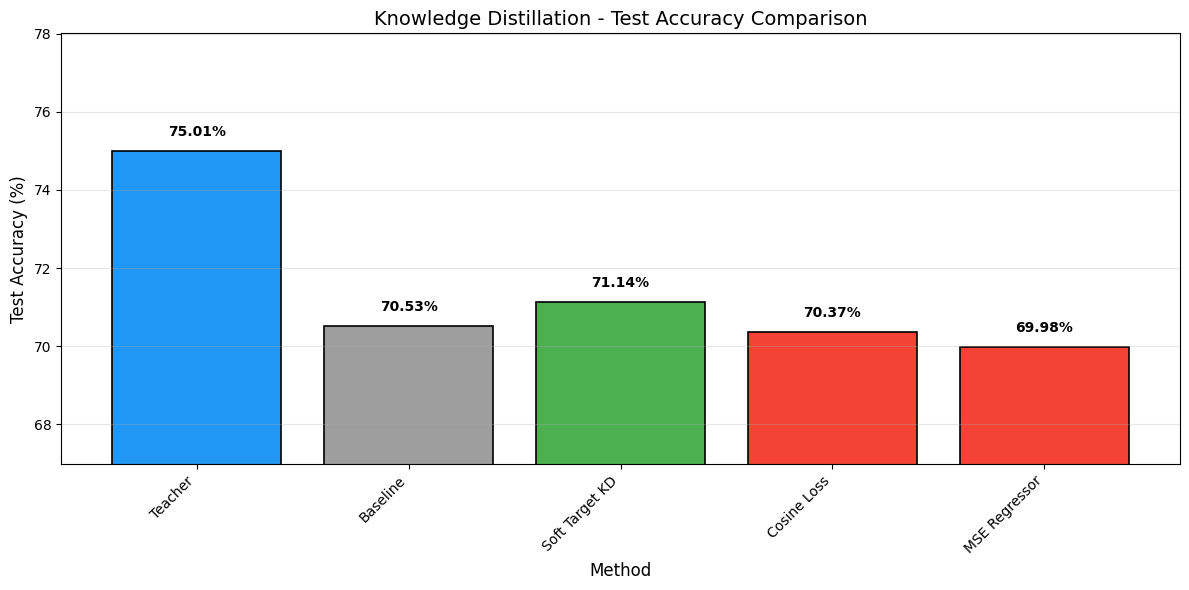

정확도 비교 차트 저장: results/accuracy_comparison.png


In [24]:
# 정확도 비교
plot_accuracy_comparison(all_accuracies)

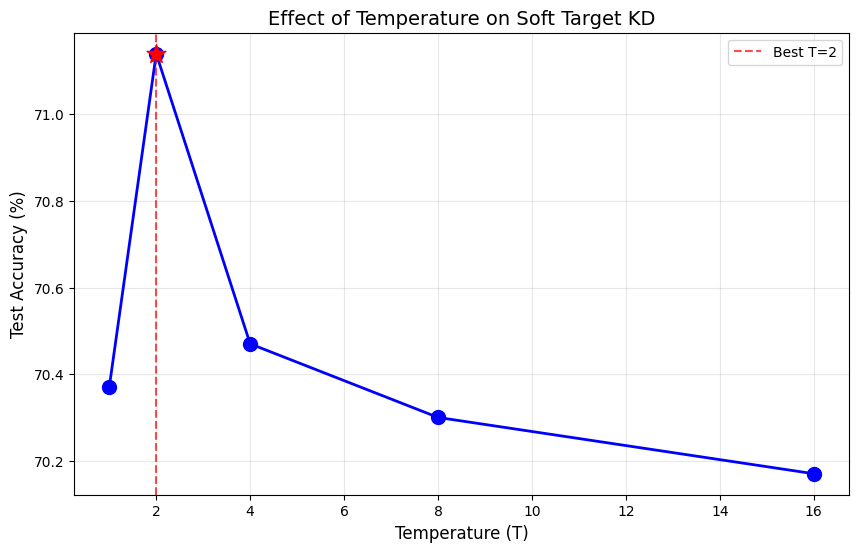

Temperature 실험 결과 저장: results/temperature_experiment.png


In [25]:
# Temperature 실험
plot_temperature_experiment(temp_results)

## 9. 최종 결과 요약

In [26]:
create_summary_table(all_accuracies)

Knowledge Distillation 실험 결과 요약

Method                              Accuracy     vs Baseline 
----------------------------------------------------------------------
Teacher                                  75.01%            -
Baseline                                 70.53%            -
Soft Target KD                           71.14%       +0.61%
Cosine Loss                              70.37%       -0.16%
MSE Regressor                            69.98%       -0.55%
----------------------------------------------------------------------

분석:
- 최고 Student 성능: Soft Target KD (71.14%)
- Baseline 대비 개선: +0.61%
- Teacher와의 격차: 3.87%

결과 요약 저장: results/summary.txt


In [27]:
print("\n" + "=" * 70)
print("실험 완료!")
print("=" * 70)
print("\n생성된 파일:")
print("- results/training_curves.png : 학습 곡선")
print("- results/accuracy_comparison.png : 정확도 비교")
print("- results/temperature_experiment.png : Temperature 효과")
print("- results/summary.txt : 결과 요약")


실험 완료!

생성된 파일:
- results/training_curves.png : 학습 곡선
- results/accuracy_comparison.png : 정확도 비교
- results/temperature_experiment.png : Temperature 효과
- results/summary.txt : 결과 요약


In [28]:
# 최종 결과 딕셔너리
final_results = {
    'accuracies': all_accuracies,
    'losses': all_losses,
    'temperature_experiment': temp_results
}

print("\n최종 정확도 요약:")
for method, acc in all_accuracies.items():
    print(f"  {method}: {acc:.2f}%")


최종 정확도 요약:
  Teacher: 75.01%
  Baseline: 70.53%
  Soft Target KD: 71.14%
  Cosine Loss: 70.37%
  MSE Regressor: 69.98%


---

## 10. 결론 및 인사이트

### Knowledge Distillation 핵심 포인트

1. **Soft Target KD**
   - Teacher의 "dark knowledge" (클래스 간 유사도 정보) 전달
   - Temperature가 높을수록 더 부드러운 분포로 정보 전달
   - 구현이 간단하고 효과적

2. **Feature-based Distillation**
   - 중간 레이어의 풍부한 representation 활용
   - Cosine Loss: 방향만 맞추면 됨
   - MSE Regressor: 학습 가능한 변환으로 더 유연

3. **하이퍼파라미터 선택**
   - Temperature: 보통 2~10 사이가 효과적
   - α (KD loss weight): 0.1~0.5 범위에서 탐색
   - 데이터셋과 모델 구조에 따라 최적값이 다름

### 실제 적용 팁

1. **Teacher가 충분히 좋아야 함**: Teacher 성능이 낮으면 KD 효과도 제한적
2. **Student 용량이 너무 작으면 한계**: 지식을 담을 수 있는 최소 용량 필요
3. **다양한 방법 조합 가능**: Soft Target + Feature-based 함께 사용 가능
4. **데이터 증강과 함께 사용**: 더 좋은 결과 가능